In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Zadanie 4d – Jawna metoda Eulera: y' = -5y, y(0)=1, h=0.5

In [3]:
lam = np.float64(-5.0)
h   = np.float64(0.5)
y0  = np.float64(1.0)
t_end = np.float64(0.5)

n_steps = int(t_end / h)

t_euler = np.float64(0.0)
y_euler = y0

print("Jawna metoda Eulera (h=0.5):")
print(f"  k=0: t={t_euler:.2f}, y={y_euler:.8f}, y_exact={np.exp(lam*t_euler):.8f}")
for k in range(n_steps):
    y_euler = y_euler + h * lam * y_euler
    t_euler = t_euler + h
    y_exact = np.exp(lam * t_euler)
    print(f"  k={k+1}: t={t_euler:.2f}, y={y_euler:.8f}, y_exact={y_exact:.8f}, blad={abs(y_euler-y_exact):.4e}")

print()
print(f"Wspolczynnik wzmocnienia: |1 + h*lambda| = |1 + {h*lam}| = {abs(1+h*lam):.4f}")
print("Poniewaz > 1, metoda jest NIESTABILNA dla h=0.5")

Jawna metoda Eulera (h=0.5):
  k=0: t=0.00, y=1.00000000, y_exact=1.00000000
  k=1: t=0.50, y=-1.50000000, y_exact=0.08208500, blad=1.5821e+00

Wspolczynnik wzmocnienia: |1 + h*lambda| = |1 + -2.5| = 1.5000
Poniewaz > 1, metoda jest NIESTABILNA dla h=0.5


## Zadanie 4f – Niejawna metoda Eulera: y' = -5y, y(0)=1, h=0.5

In [4]:
t_ie = np.float64(0.0)
y_ie = y0

print("Niejawna metoda Eulera (h=0.5):")
print(f"  k=0: t={t_ie:.2f}, y={y_ie:.8f}")
for k in range(n_steps):
    y_ie = y_ie / (np.float64(1.0) - h * lam)
    t_ie = t_ie + h
    y_exact = np.exp(lam * t_ie)
    print(f"  k={k+1}: t={t_ie:.2f}, y={y_ie:.8f}, y_exact={y_exact:.8f}, blad={abs(y_ie-y_exact):.4e}")

print()
print(f"Wspolczynnik wzmocnienia niejawnego: 1/(1+5h) = 1/{1+5*float(h):.1f} = {1/(1+5*float(h)):.4f}")
print("Poniewaz < 1, metoda jest STABILNA dla h=0.5")

Niejawna metoda Eulera (h=0.5):
  k=0: t=0.00, y=1.00000000
  k=1: t=0.50, y=0.28571429, y_exact=0.08208500, blad=2.0363e-01

Wspolczynnik wzmocnienia niejawnego: 1/(1+5h) = 1/3.5 = 0.2857
Poniewaz < 1, metoda jest STABILNA dla h=0.5


## Zadanie 6 – Metoda Eulera dla y' = alpha*t^(alpha-1), y(0)=0

Rozwiazanie dokladne: y(t) = t^alpha

In [5]:
def euler_solve(alpha, h, t_end=1.0):
    alpha = np.float64(alpha)
    h     = np.float64(h)
    t     = np.float64(0.0)
    y     = np.float64(0.0)
    ts, ys = [t], [y]
    while t < t_end - h/2:
        dydt = alpha * t**(alpha - np.float64(1.0)) if t > 0 else np.float64(0.0)
        y = y + h * dydt
        t = t + h
        ts.append(t)
        ys.append(y)
    return np.array(ts, dtype=np.float64), np.array(ys, dtype=np.float64)

alphas = [2.5, 1.5, 1.1]
hs     = [0.2, 0.1, 0.05]
t_end  = 1.0

print(f"{'alpha':>6}  {'h':>6}  {'blad_max':>12}  {'blad_t1':>12}")
print("-" * 44)

all_results = {}

for alpha in alphas:
    errors_t1 = []
    for h in hs:
        ts, ys = euler_solve(alpha, h, t_end)
        y_exact = ts**alpha
        err = np.abs(ys - y_exact)
        err_t1 = float(err[-1])
        errors_t1.append(err_t1)
        print(f"{alpha:>6.1f}  {h:>6.2f}  {np.max(err):>12.6e}  {err_t1:>12.6e}")
    all_results[alpha] = errors_t1
    print()

print("Empiryczny rzad zbieznosci (t=1):")
for alpha in alphas:
    errs = all_results[alpha]
    r1 = np.log(errs[0]/errs[1]) / np.log(hs[0]/hs[1])
    r2 = np.log(errs[1]/errs[2]) / np.log(hs[1]/hs[2])
    print(f"  alpha={alpha}: r(h=0.2->0.1)={r1:.3f},  r(h=0.1->0.05)={r2:.3f}  (teoret. min(1, alpha))")

 alpha       h      blad_max       blad_t1
--------------------------------------------
   2.5    0.20  2.386377e-01  2.386377e-01
   2.5    0.10  1.220763e-01  1.220763e-01
   2.5    0.05  6.175436e-02  6.175436e-02

   1.5    0.20  1.753921e-01  1.753921e-01
   1.5    0.10  8.423599e-02  8.423599e-02
   1.5    0.05  4.083011e-02  4.083011e-02

   1.1    0.20  1.877784e-01  1.877784e-01
   1.1    0.10  9.136412e-02  9.136412e-02
   1.1    0.05  4.448430e-02  4.448430e-02

Empiryczny rzad zbieznosci (t=1):
  alpha=2.5: r(h=0.2->0.1)=0.967,  r(h=0.1->0.05)=0.983  (teoret. min(1, alpha))
  alpha=1.5: r(h=0.2->0.1)=1.058,  r(h=0.1->0.05)=1.045  (teoret. min(1, alpha))
  alpha=1.1: r(h=0.2->0.1)=1.039,  r(h=0.1->0.05)=1.038  (teoret. min(1, alpha))


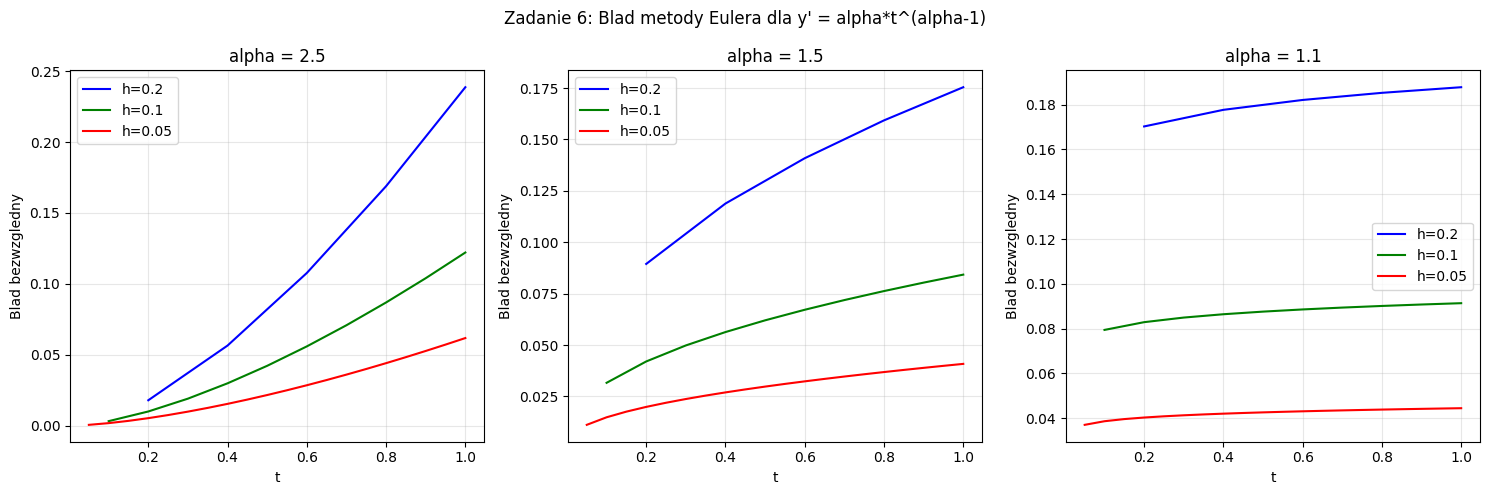

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors_h = ['b', 'g', 'r']

for ax, alpha in zip(axes, alphas):
    for h, col in zip(hs, colors_h):
        ts, ys = euler_solve(alpha, h, t_end)
        y_exact = ts**alpha
        err = np.abs(ys - y_exact) 
        mask = err > 0
        if mask.any():
            ax.plot(ts[mask], err[mask], color=col, label=f'h={h}')
    ax.set_title(f'alpha = {alpha}')
    ax.set_xlabel('t')
    ax.set_ylabel('Blad bezwzgledny')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Zadanie 6: Blad metody Eulera dla y\' = alpha*t^(alpha-1)')
plt.tight_layout()
plt.show()

In [7]:
print("Wyjasnienie wynikow:")
print()
print("Metoda Eulera ma rzad zbieznosci O(h^p), gdzie p = min(1, alpha).")
print("Prawostronna pochodna y'(t) = alpha*t^(alpha-1) jest osobliwa w t=0 gdy alpha < 1.")
print()
for alpha in alphas:
    p = min(1.0, float(alpha))
    print(f"  alpha={alpha}: pochodna y'(t)=alpha*t^(alpha-1), gladkosc w t=0: C^{alpha:.1f}")
    print(f"           Oczekiwany rzad zbieznosci: p = min(1, alpha) = {p}")

Wyjasnienie wynikow:

Metoda Eulera ma rzad zbieznosci O(h^p), gdzie p = min(1, alpha).
Prawostronna pochodna y'(t) = alpha*t^(alpha-1) jest osobliwa w t=0 gdy alpha < 1.

  alpha=2.5: pochodna y'(t)=alpha*t^(alpha-1), gladkosc w t=0: C^2.5
           Oczekiwany rzad zbieznosci: p = min(1, alpha) = 1.0
  alpha=1.5: pochodna y'(t)=alpha*t^(alpha-1), gladkosc w t=0: C^1.5
           Oczekiwany rzad zbieznosci: p = min(1, alpha) = 1.0
  alpha=1.1: pochodna y'(t)=alpha*t^(alpha-1), gladkosc w t=0: C^1.1
           Oczekiwany rzad zbieznosci: p = min(1, alpha) = 1.0
